# Y-axis orientation — north-up reads, whatever the file stores

NetCDF producers write their rows in whichever order they like: most store latitude **south→north** (row 0 at the
south edge), some store it north→south, and satellite products store packed scan angles whose direction isn't even
visible in the raw numbers. Rasters follow one convention: **row 0 is the north edge**.

`pyramids` reconciles the two on read. Whatever the storage order, `read_array()`, `plot()`, and the `lat` / `y`
coordinate accessors always come back **north-up** — you never have to know how the file was written. This notebook
shows that guarantee holding across the three storage layouts you'll actually meet, and what would go wrong without
it ([#705](https://github.com/serapeum-org/pyramids/issues/705) was exactly that failure):

| file | latitude / y stored | what `pyramids` does |
|---|---|---|
| NOAH precipitation (global) | south → north | reverses the rows |
| NCEP `air` temperature | north → south | leaves them alone |
| GOES-16 satellite imagery | packed scan angle, direction hidden by a negative `scale_factor` | reads the *physical* direction, leaves them alone |

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np

from pyramids.netcdf import NetCDF

DATA = Path('../../../../examples/data/netcdf/samples')

2026-07-20 02:41:42 | INFO | pyramids.base.config | Logging is configured.


## Case 1 — latitude stored south → north (the common case)

This NOAH precipitation file is a real global 0.5° grid whose latitude runs −89.75° → 89.75° in storage: row 0 of
the file is the *south* edge. After opening, everything is already north-up — the first latitude is the northernmost,
and the geotransform's pixel height is negative (the raster-convention way of saying "rows go downward from the
north edge").

In [2]:
noah_file = NetCDF.read_file(DATA / 'cf__6v__1d2-2d4__geog__y-asc.nc')
noah = noah_file.get_variable('Band1')
print(f'first latitude : {noah.lat[0]:7.2f}   (northernmost)')
print(f'last  latitude : {noah.lat[-1]:7.2f}   (southernmost)')
print(f'pixel height   : {noah.geotransform[5]:7.2f}   (negative = north-up)')

first latitude :   89.75   (northernmost)
last  latitude :  -89.75   (southernmost)
pixel height   :   -0.50   (negative = north-up)


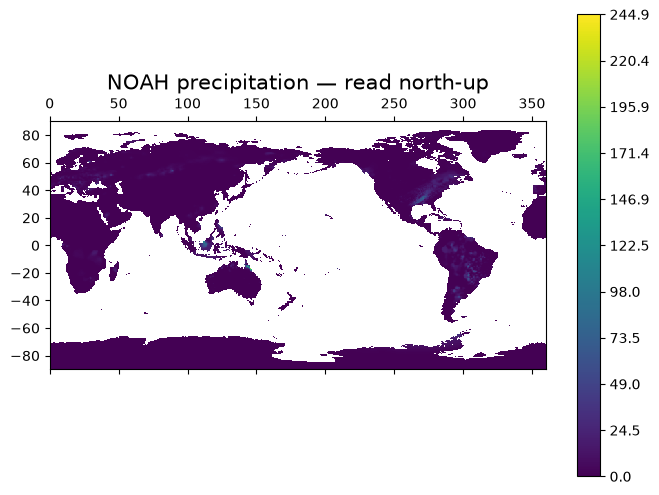

In [3]:
glyph = noah.plot(title='NOAH precipitation — read north-up', cmap='viridis')

The world is the right way up — the Arctic at the top, Antarctica at the bottom — even though the file stores
its rows the other way round. Had `pyramids` trusted the storage order and left the rows as written, the same
north-up geotransform would have rendered every continent upside down: a silent vertical mirror, no error. On a
*regional* file that mirror still looks plausible, so every value sampled at a coordinate would be wrong without any
visible clue — which is exactly what [#705](https://github.com/serapeum-org/pyramids/issues/705) was.

## Case 2 — latitude stored north → south (nothing to undo)

Some producers already write north-first. This NCEP reanalysis air-temperature file stores latitude 75° → 15°, so
its rows already match the raster convention and `pyramids` leaves them untouched. The point of this case: the API
looks **identical**. You cannot tell from the outside whether a flip happened — that's the contract.

In [4]:
air_file = NetCDF.read_file(DATA / 'coards__4v__1d3-3d1__y-desc.nc')
air = air_file.get_variable('air')
print(f'first latitude : {air.lat[0]:7.2f}   (northernmost)')
print(f'last  latitude : {air.lat[-1]:7.2f}   (southernmost)')
print(f'pixel height   : {air.geotransform[5]:7.2f}   (negative = north-up)')

first latitude :   75.00   (northernmost)
last  latitude :   15.00   (southernmost)
pixel height   :   -2.50   (negative = north-up)


Where is this? The grid is regional and its longitudes are stored in the 0–360 frame (200°–330° = 160°W–30°W),
where the coastline (defined in −180…180) cannot be drawn. Shift the grid's origin into the −180…180 frame and lay
the coastline on top — it's North America:

In [5]:
first_step = air.read_array(band=0, unpack=True)  # unpack the int16 values to Kelvin
geo = list(air.geotransform)
geo[0] = geo[0] - 360  # 200..330 E  ->  -160..-30 (same grid, shifted frame)
shifted_file = NetCDF.create_from_array(
    arr=first_step, geo=tuple(geo), epsg=4326, variable_name='air'
)
shifted = shifted_file.get_variable('air')

<Axes: title={'center': 'NCEP air temperature over North America — read north-up'}>

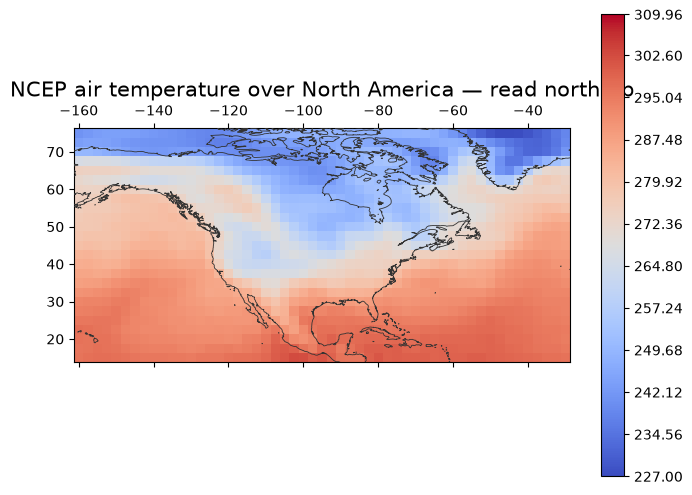

In [6]:
glyph = shifted.plot(
    title='NCEP air temperature over North America — read north-up', cmap='coolwarm'
)
glyph.add_features('coastline', '50m', zorder=5)

## Case 3 — the satellite trap: packed coordinates ([#705](https://github.com/serapeum-org/pyramids/issues/705))

A real GOES-16 granule (Cloud & Moisture Imagery). Its `y` coordinate is the satellite's scan angle, stored as
`int16` and unpacked through `scale_factor ≈ −5.6e-05` — **negative**. So the integers *stored in the file ascend*
while the *physical coordinate descends*: the storage order and the real direction point opposite ways, and any
reader that judges orientation from the raw storage (or from anything derived from it) flips an image that was
already north-up.

`pyramids` decides from the physical coordinate. The `y` accessor shows the result — projected metres, descending,
row 0 at the top of the scan:

In [7]:
goes_file = NetCDF.read_file(DATA / 'cf__9v__1d7-2d2__geos__y-desc.nc')
goes = goes_file.get_variable('CMI')
print(f'first y : {goes.y[0]:>12,.0f} m   (top of the image)')
print(f'last  y : {goes.y[-1]:>12,.0f} m')
print(f'pixel   : {goes.geotransform[1]:>12,.0f} m   (a ~2 km geostationary grid)')

2026-07-20 02:41:43 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


first y :    1,502,011 m   (top of the image)
last  y :      502,006 m
pixel   :        2,004 m   (a ~2 km geostationary grid)


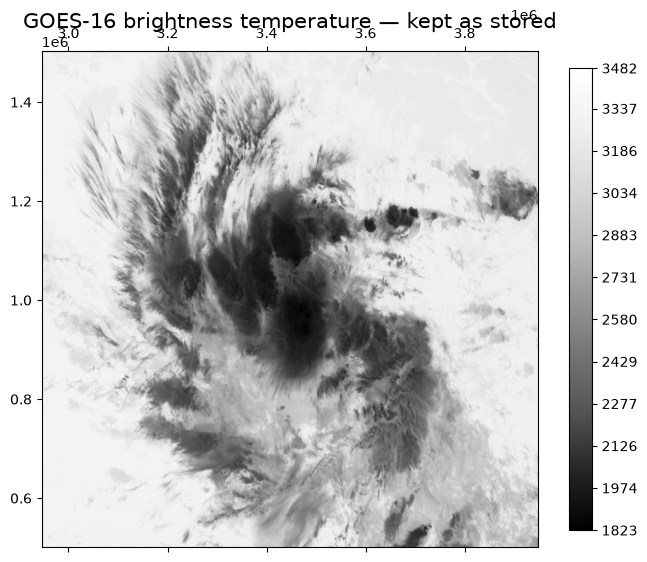

In [8]:
glyph = goes.plot(
    title='GOES-16 brightness temperature — kept as stored', cmap='Greys_r'
)

The orientation is not something special about `CMI`. The scan-angle `y` axis belongs to the **file**, so every
variable sharing that grid is normalized by the same rule. The granule also carries `DQF` (per-pixel data-quality
flags) on the identical grid — a completely different variable, read exactly the same way up:

In [9]:
dqf = goes_file.get_variable('DQF')
print(f'DQF shares CMI\'s y coordinate : {np.array_equal(dqf.y, goes.y)}')
print(
    f'DQF first / last y            : {dqf.y[0]:>12,.0f} .. {dqf.y[-1]:>12,.0f} m   (same descending grid)'
)
print(f'DQF pixel height < 0 (north-up): {dqf.geotransform[5] < 0}')

2026-07-20 02:41:44 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


DQF shares CMI's y coordinate : True
DQF first / last y            :    1,502,011 ..      502,006 m   (same descending grid)
DQF pixel height < 0 (north-up): True


Same `y` coordinate, same north-up geotransform — the flip decision was made once, from the coordinate, and
applies to whatever you read from the file. (`DQF` is all-zeros here — every pixel is good quality — so there is
nothing to *plot*; `CMI` is the one whose cloud field makes the orientation visible.)

Before the fix, this exact kind of file came back **vertically mirrored** — no error, plausible-looking clouds,
wrong values at every coordinate. Where is this scene? The native plot above cannot say: its axes are scan metres
from the sub-satellite point, and web-tile basemaps need an EPSG code, which a custom geostationary CRS does not
have. So reproject to lon/lat first, then put satellite imagery underneath with the glyph's `add_tiles` (it already
knows the CRS from `to_crs`). The scene turns out to be a tropical system in the open Atlantic, just north-east of
the South American coast — and with the old,
mirrored read every cloud band landed at the wrong latitude, so any value sampled at real storm coordinates was
silently wrong.

<Axes: title={'center': 'A tropical system in the open Atlantic'}>

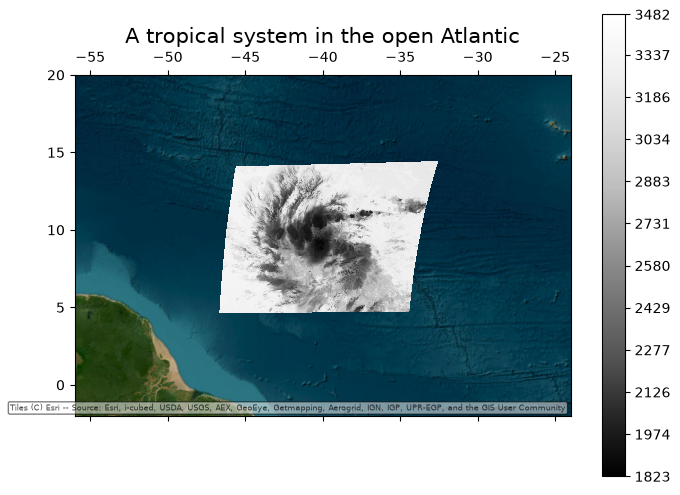

In [10]:
geographic = goes.to_crs(4326)
glyph = geographic.plot(title='A tropical system in the open Atlantic', cmap='Greys_r')
# pad the view a little, then fetch imagery tiles for that extent (warped to lon/lat)
glyph.ax.set_xlim(-56, -24)
glyph.ax.set_ylim(-2, 20)
glyph.add_tiles(source='Esri.WorldImagery')  # glyph carries the CRS from to_crs(4326)

## One guarantee, every read path

The same normalization applies no matter how you read: the eager `read_array()` and the chunked (dask-backed)
`read_array(chunks=...)` return identical, north-up arrays. It also covers layouts not shown here — projected grids
stored bottom-up and even a longitude stored east→west (column 0 always ends up at the *west* edge).

In [11]:
for name, variable in [
    ('cf__6v__1d2-2d4__geog__y-asc.nc', 'Band1'),
    ('coards__4v__1d3-3d1__y-desc.nc', 'air'),
    ('cf__9v__1d7-2d2__geos__y-desc.nc', 'CMI'),
]:
    container = NetCDF.read_file(DATA / name)
    var = container.get_variable(variable)
    eager = var.read_array()
    chunked = var.read_array(chunks='auto')
    same = np.array_equal(np.asarray(chunked), eager)
    print(f'{name:38s} {variable:6s} chunked == eager: {same}')

2026-07-20 02:41:45 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


cf__6v__1d2-2d4__geog__y-asc.nc        Band1  chunked == eager: True
coards__4v__1d3-3d1__y-desc.nc         air    chunked == eager: True
cf__9v__1d7-2d2__geos__y-desc.nc       CMI    chunked == eager: True


## Takeaway

- Files store rows in any order; rasters are **row 0 = north**. `pyramids` converts on read, every time.
- `read_array()`, `plot()`, `lat` / `y`, and the geotransform are always north-up — across geographic, projected,
  and geostationary files, and across the eager and chunked read paths alike.
- The one storage layout that fools order-based readers is a coordinate packed with a **negative** `scale_factor`
  (the GOES case): the stored numbers run opposite to the physical axis. Deciding from the physical coordinate is
  what closed [#705](https://github.com/serapeum-org/pyramids/issues/705).